# Acquire + analyse — one configuration

In [1]:
TITLE    = "single_700-10_520-40_420-10___NIR3"  # names data/ and results/ folders for THIS configuration
DAY      = "Jun23"
MATERIAL = "CdTe110"  # sample
POWER_MW = 77

# --- the optical configuration under test (saved into the pkl) ---
CONFIG = {
    "P1": False,                                                        # pre pol
    "P3": False,                                                        # post pol
    "filters": {"H3": "700-10", "H4": "520-40", "H5": "420-10"},        # per-harmonic bandpass (center-bandwidth)
    "filter_layout": {"H3": "single", "H4": "single", "H5": "single"},  # per-channel = one per arm // single = shared by both arms
    "density": "NIR3"
}

# --- short test acquisition ---
CHUNK_MINUTES = 1.0
MAX_CHUNKS    = 2

# --- time tagger ---
CHANNELS        = [1, 2, 3, 4, 5, 6]
MODE_ON_CHANNEL = ["H3T", "H3R", "H4T", "H4R", "H5T", "H5R"]
DELAYS_PS       = [0, 0, 0, 0, 0, 0]
TRIGGER_V       = 0.5
BINWIDTH_PS     = 100
NUM_BINS        = 50000
COINC_WINDOW_PS = 25000
REP_RATE_HZ     = 18.6e6
WAVELENGTH_NM   = 2100

LIVE_HARDWARE = True
PRM1_SERIAL   = "27264707"

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src" / "core.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

DATA_DIR    = ROOT / "data" / DAY / TITLE
RESULTS_DIR = ROOT / "results"
print("Project root:", ROOT)
print("Data ->", DATA_DIR)

Project root: c:\Users\QUANTUM\Desktop\Quantum_SHHG
Data -> c:\Users\QUANTUM\Desktop\Quantum_SHHG\data\Jun23\single_700-10_520-40_420-10___NIR3


## 1. Acquire

In [3]:
from src.acquisition import (Acquisition, AcquisitionConfig, LaserParams, TimeTaggerParams, ChunkingParams, ScanPoint)
from src.measurement import CombinedRecorder

RUN_PATH = None

if LIVE_HARDWARE:
    cfg = AcquisitionConfig(
        base_dir=DATA_DIR,
        material=MATERIAL,
        experiment_type="g2_heralded_virtual",
        configuration=CONFIG,
        laser=LaserParams(rep_rate_hz=REP_RATE_HZ, wavelength_nm=WAVELENGTH_NM),
        timetagging=TimeTaggerParams(
            channels=CHANNELS, mode_on_channel=MODE_ON_CHANNEL,
            trigger_levels_v=TRIGGER_V, delays_ps=DELAYS_PS,
            binwidth_ps=BINWIDTH_PS, num_bins=NUM_BINS,
            coincidence_window_ps=COINC_WINDOW_PS,
        ),
        chunking=ChunkingParams(enabled=True, chunk_minutes=CHUNK_MINUTES, max_chunks=MAX_CHUNKS, stop_when_reached=False),
    )
    with Acquisition(cfg, recorder=CombinedRecorder()) as acq:
        acq.run_chunked(ScanPoint(power_mw=POWER_MW, label=TITLE))
        RUN_PATH = acq.save_dir
    print("Acquired ->", RUN_PATH)
else:
    print("[offline] LIVE_HARDWARE is False — set RUN_PATH manually below to analyse an existing run.")

2026-06-23 16:37:28,959 [INFO]  ==================== ACQUISITION SETUP ====================
2026-06-23 16:37:29,101 [INFO]  Found 1 connected Time Tagger(s)
2026-06-23 16:37:31,970 [INFO]  Time Tagger initialised (serial=225000139A, model=Time Tagger Ultra, resolution=Standard).
2026-06-23 16:37:31,971 [INFO]  Trigger level ch 1: 0.500 V
2026-06-23 16:37:31,972 [INFO]  Trigger level ch 2: 0.500 V
2026-06-23 16:37:31,973 [INFO]  Trigger level ch 3: 0.500 V
2026-06-23 16:37:31,974 [INFO]  Trigger level ch 4: 0.500 V
2026-06-23 16:37:31,975 [INFO]  Trigger level ch 5: 0.500 V
2026-06-23 16:37:31,977 [INFO]  Trigger level ch 6: 0.500 V
2026-06-23 16:37:31,978 [INFO]  Recorder: combined
2026-06-23 16:37:31,980 [INFO]  Chunked acquisition 'single_700-10_520-40_420-10___NIR3_num0' (chunk=1.00 min, max=2).
2026-06-23 16:37:31,981 [INFO]  Chunk 1/2 | elapsed 1.0 min
2026-06-23 16:37:31,982 [INFO]  Correlation recording: mode=g2_heralded_virtual, virtual=True, phys_hist=True
2026-06-23 16:37:31,

Acquired -> c:\Users\QUANTUM\Desktop\Quantum_SHHG\data\Jun23\single_700-10_520-40_420-10___NIR3\2026-06-23_16-37-28_g2_heralded_virtual


In [4]:
if RUN_PATH is None:
    RUN_PATH = ROOT / "data" / "Jun18" / "RMS" / "337-335"
print("Analysing:", RUN_PATH)

Analysing: c:\Users\QUANTUM\Desktop\Quantum_SHHG\data\Jun23\single_700-10_520-40_420-10___NIR3\2026-06-23_16-37-28_g2_heralded_virtual


## 2. Analyse + save

Saves every figure under `results/<date>/<TITLE>/{coherence,g2,R}/` (`grid.png` + one PNG per
pair). Comment out any of `coherence` / `g2` / `R` you don't need. `show_singles=True` also
displays the per-pair plots interactively (they are always saved regardless).

AnalysisReport 'single_700-10_520-40_420-10___NIR3': 1 run(s) (single), source=physical
  -> results: c:\Users\QUANTUM\Desktop\Quantum_SHHG\results\2026-06-23\single_700-10_520-40_420-10___NIR3


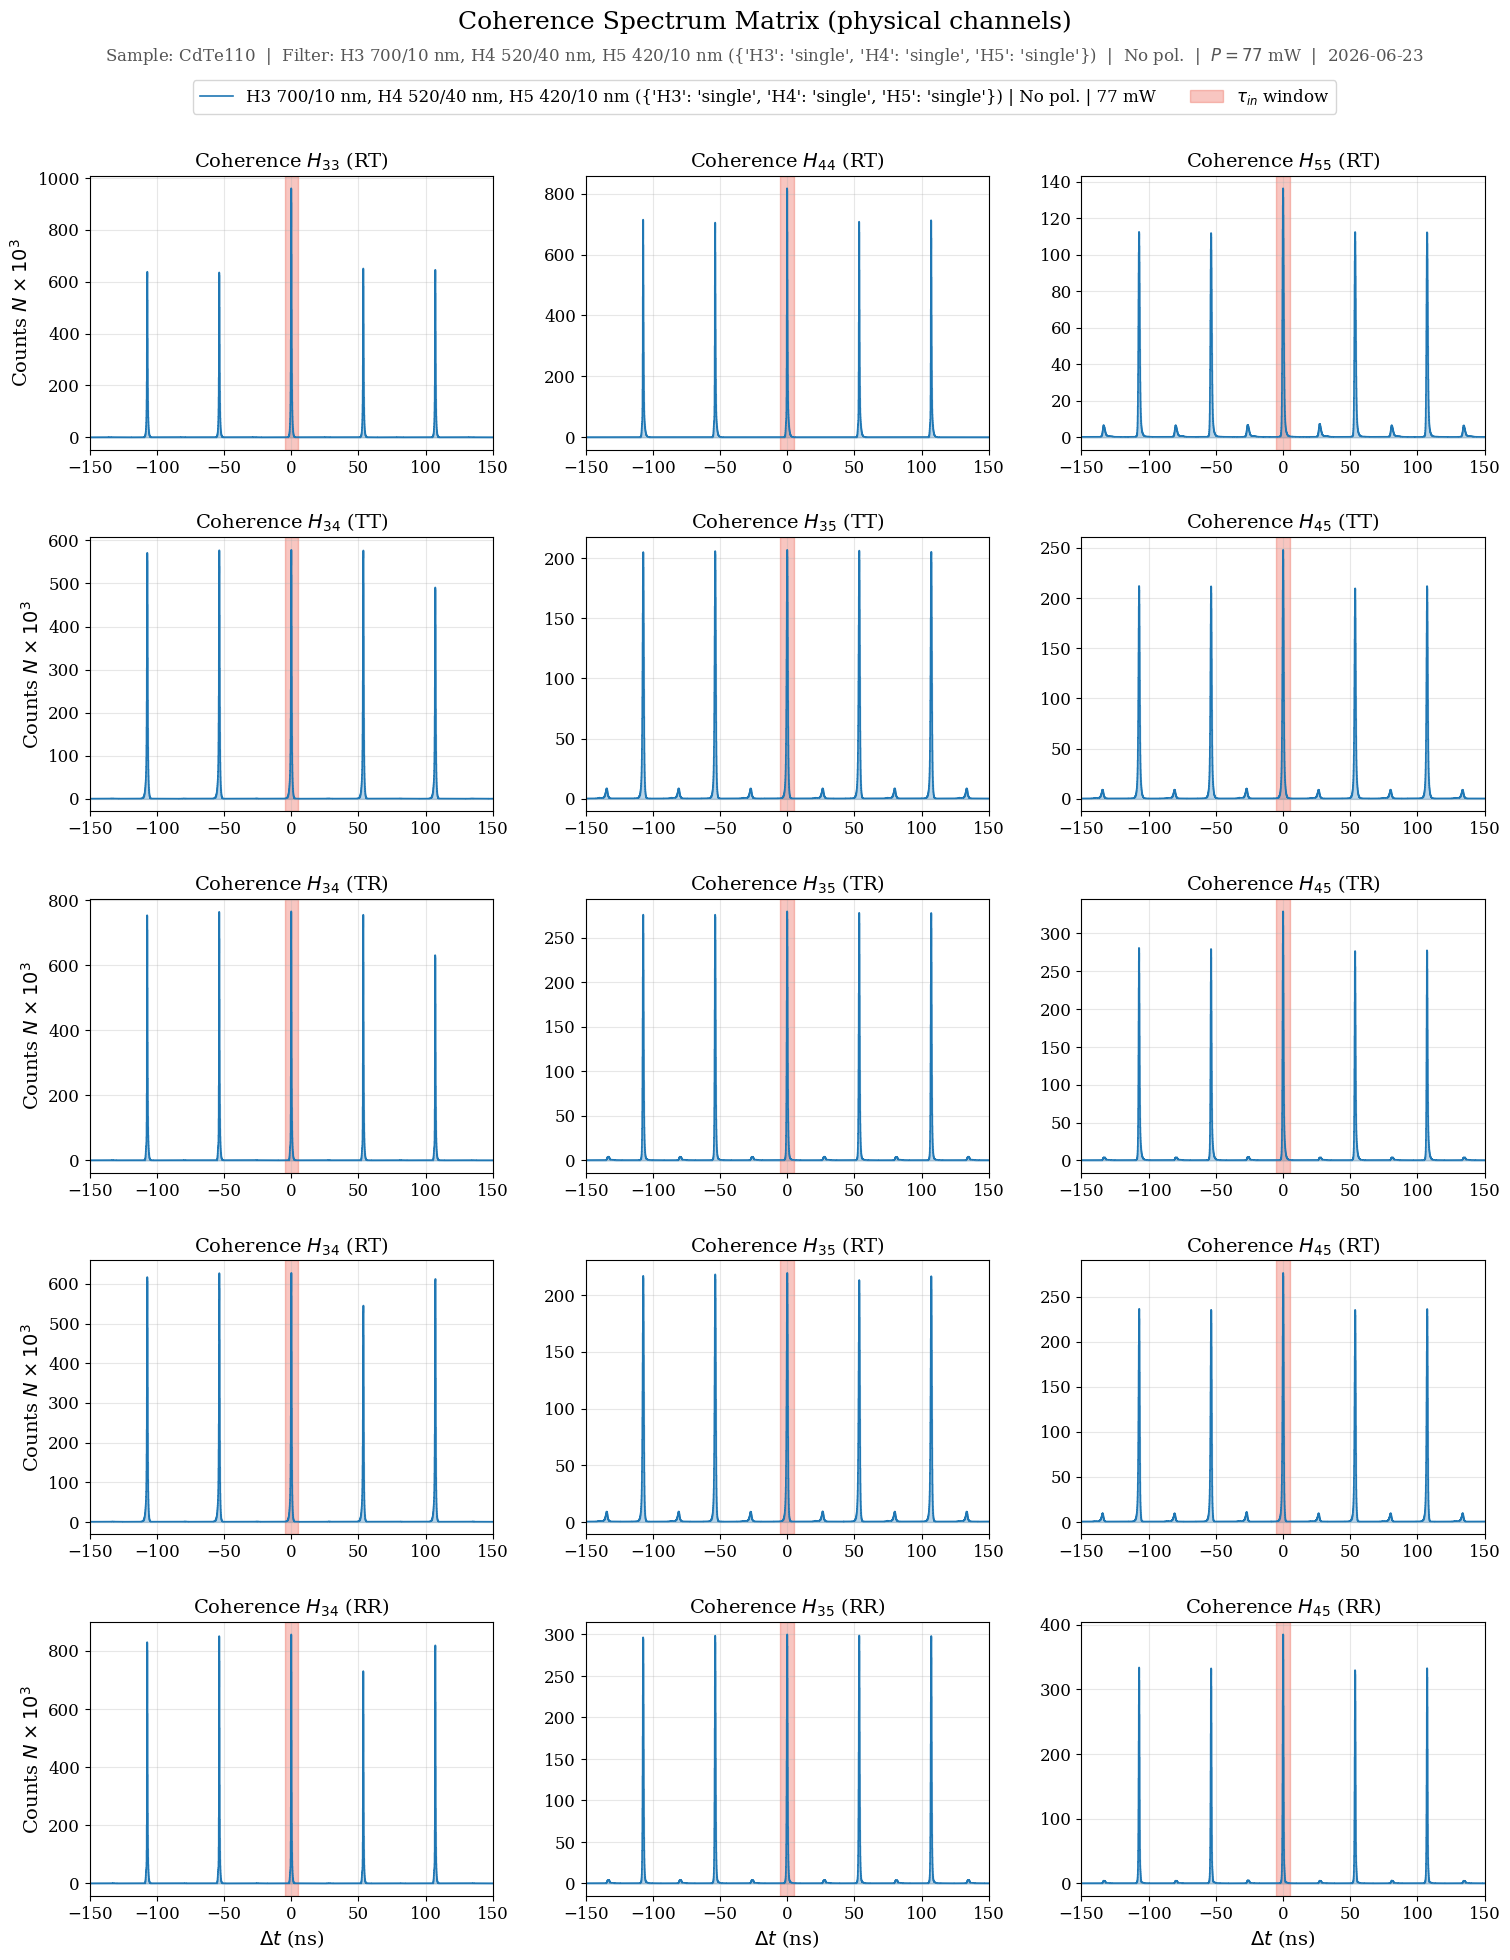

  coherence -> c:\Users\QUANTUM\Desktop\Quantum_SHHG\results\2026-06-23\single_700-10_520-40_420-10___NIR3\coherence


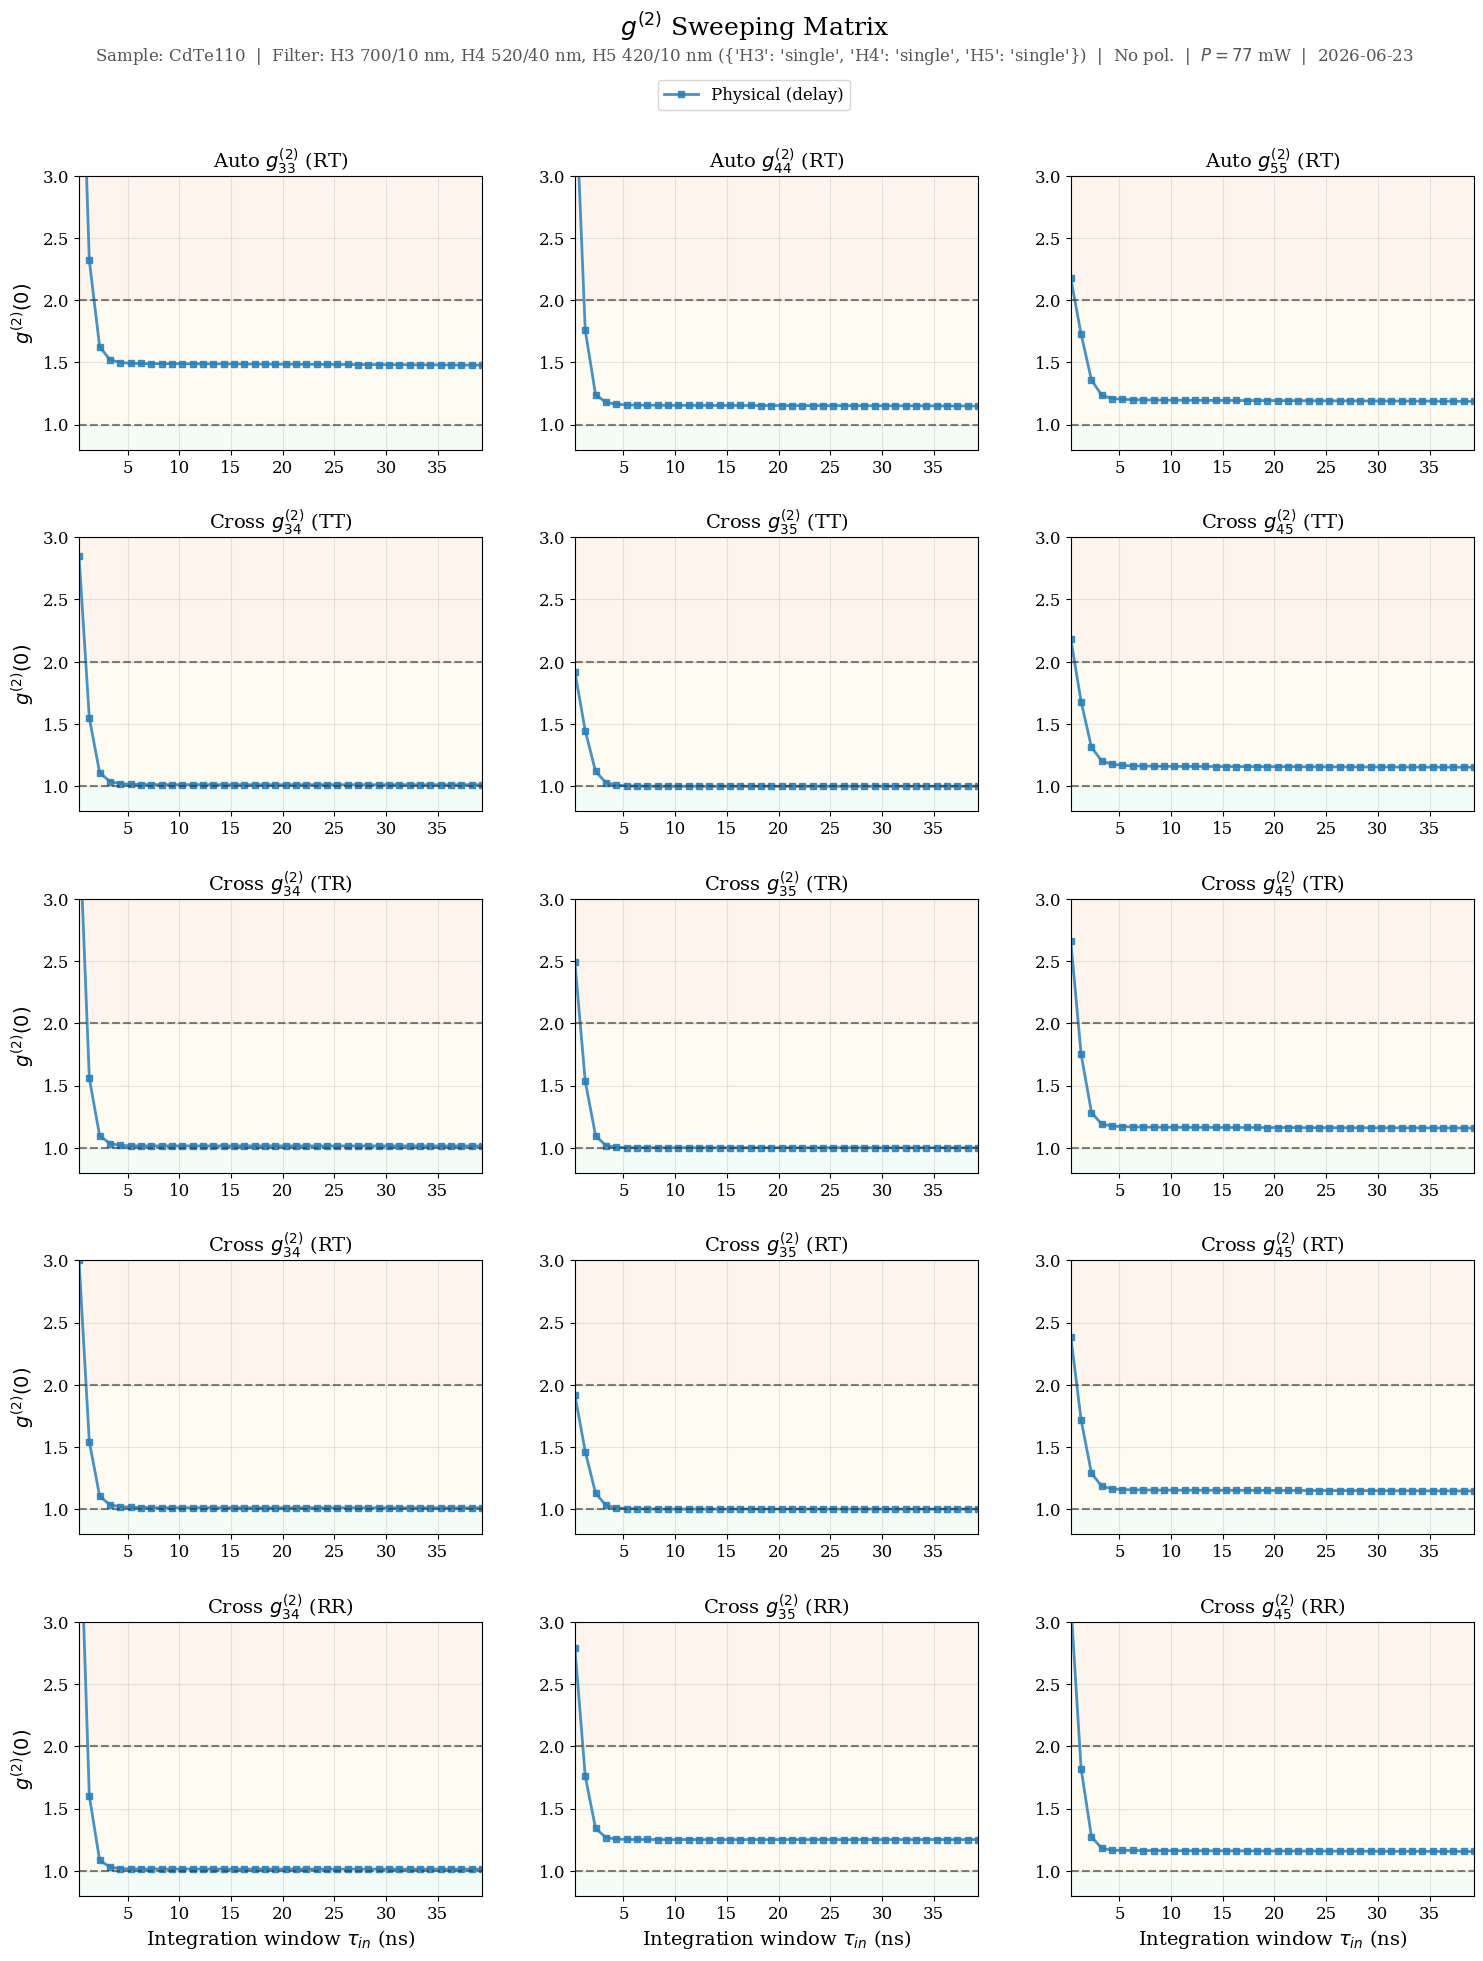

  g2        -> c:\Users\QUANTUM\Desktop\Quantum_SHHG\results\2026-06-23\single_700-10_520-40_420-10___NIR3\g2


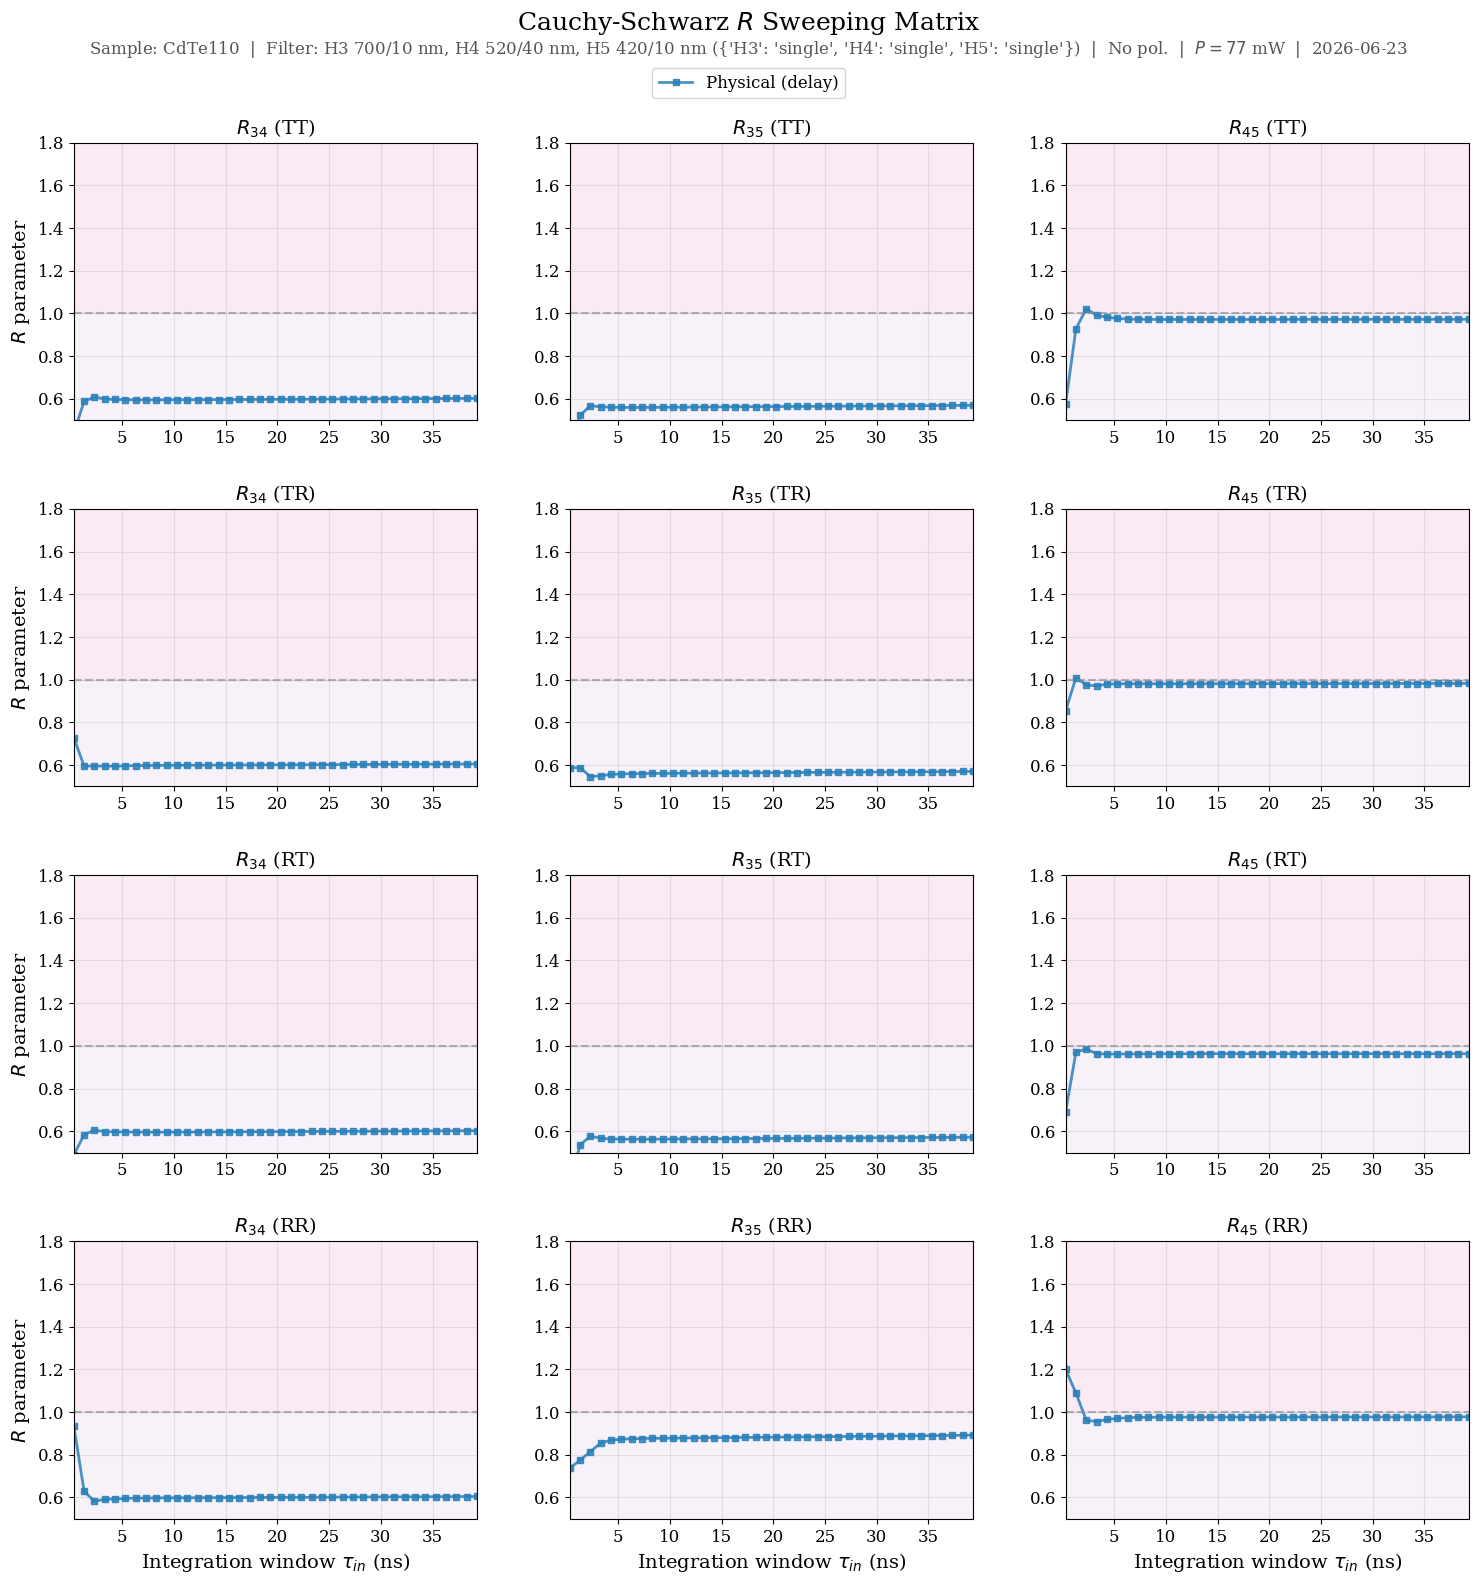

  R         -> c:\Users\QUANTUM\Desktop\Quantum_SHHG\results\2026-06-23\single_700-10_520-40_420-10___NIR3\R


In [8]:
from src.report import AnalysisReport

rep = AnalysisReport(RUN_PATH, title=TITLE, results_root=RESULTS_DIR)

rep.coherence(xlim=150, integration_window_ns=10, show_singles=False)
rep.g2(methods=["delay"], ylim=(0.8, 3),tau_min=0.3, tau_max=40, step=1.0, show_singles=False, num_side_peaks=5)
rep.R(methods=["delay"], ylim=(0.5, 1.8), tau_min=0.3, tau_max=40, step=1.0, show_singles=False, num_side_peaks=5)

## 3. Quick zoom

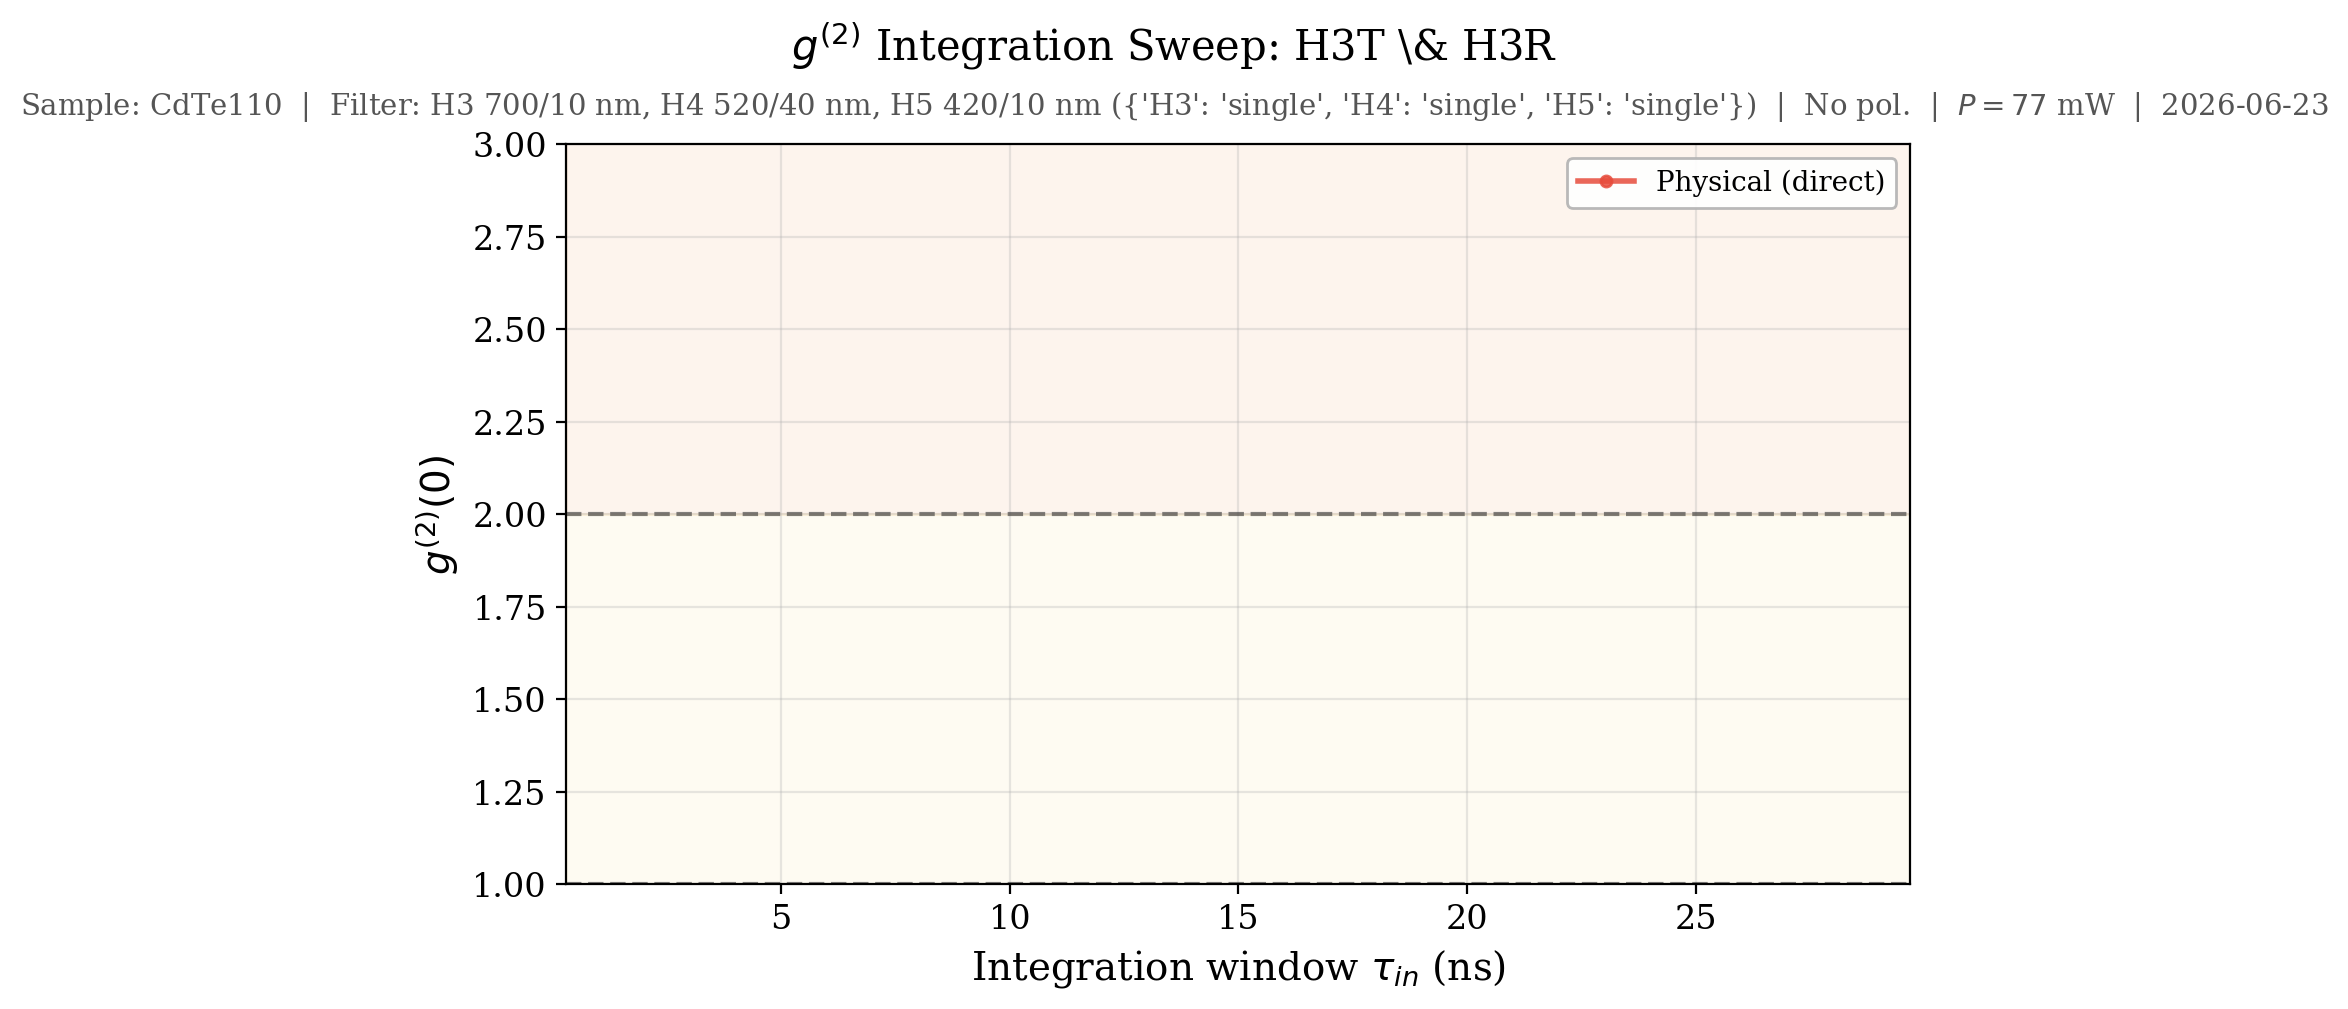

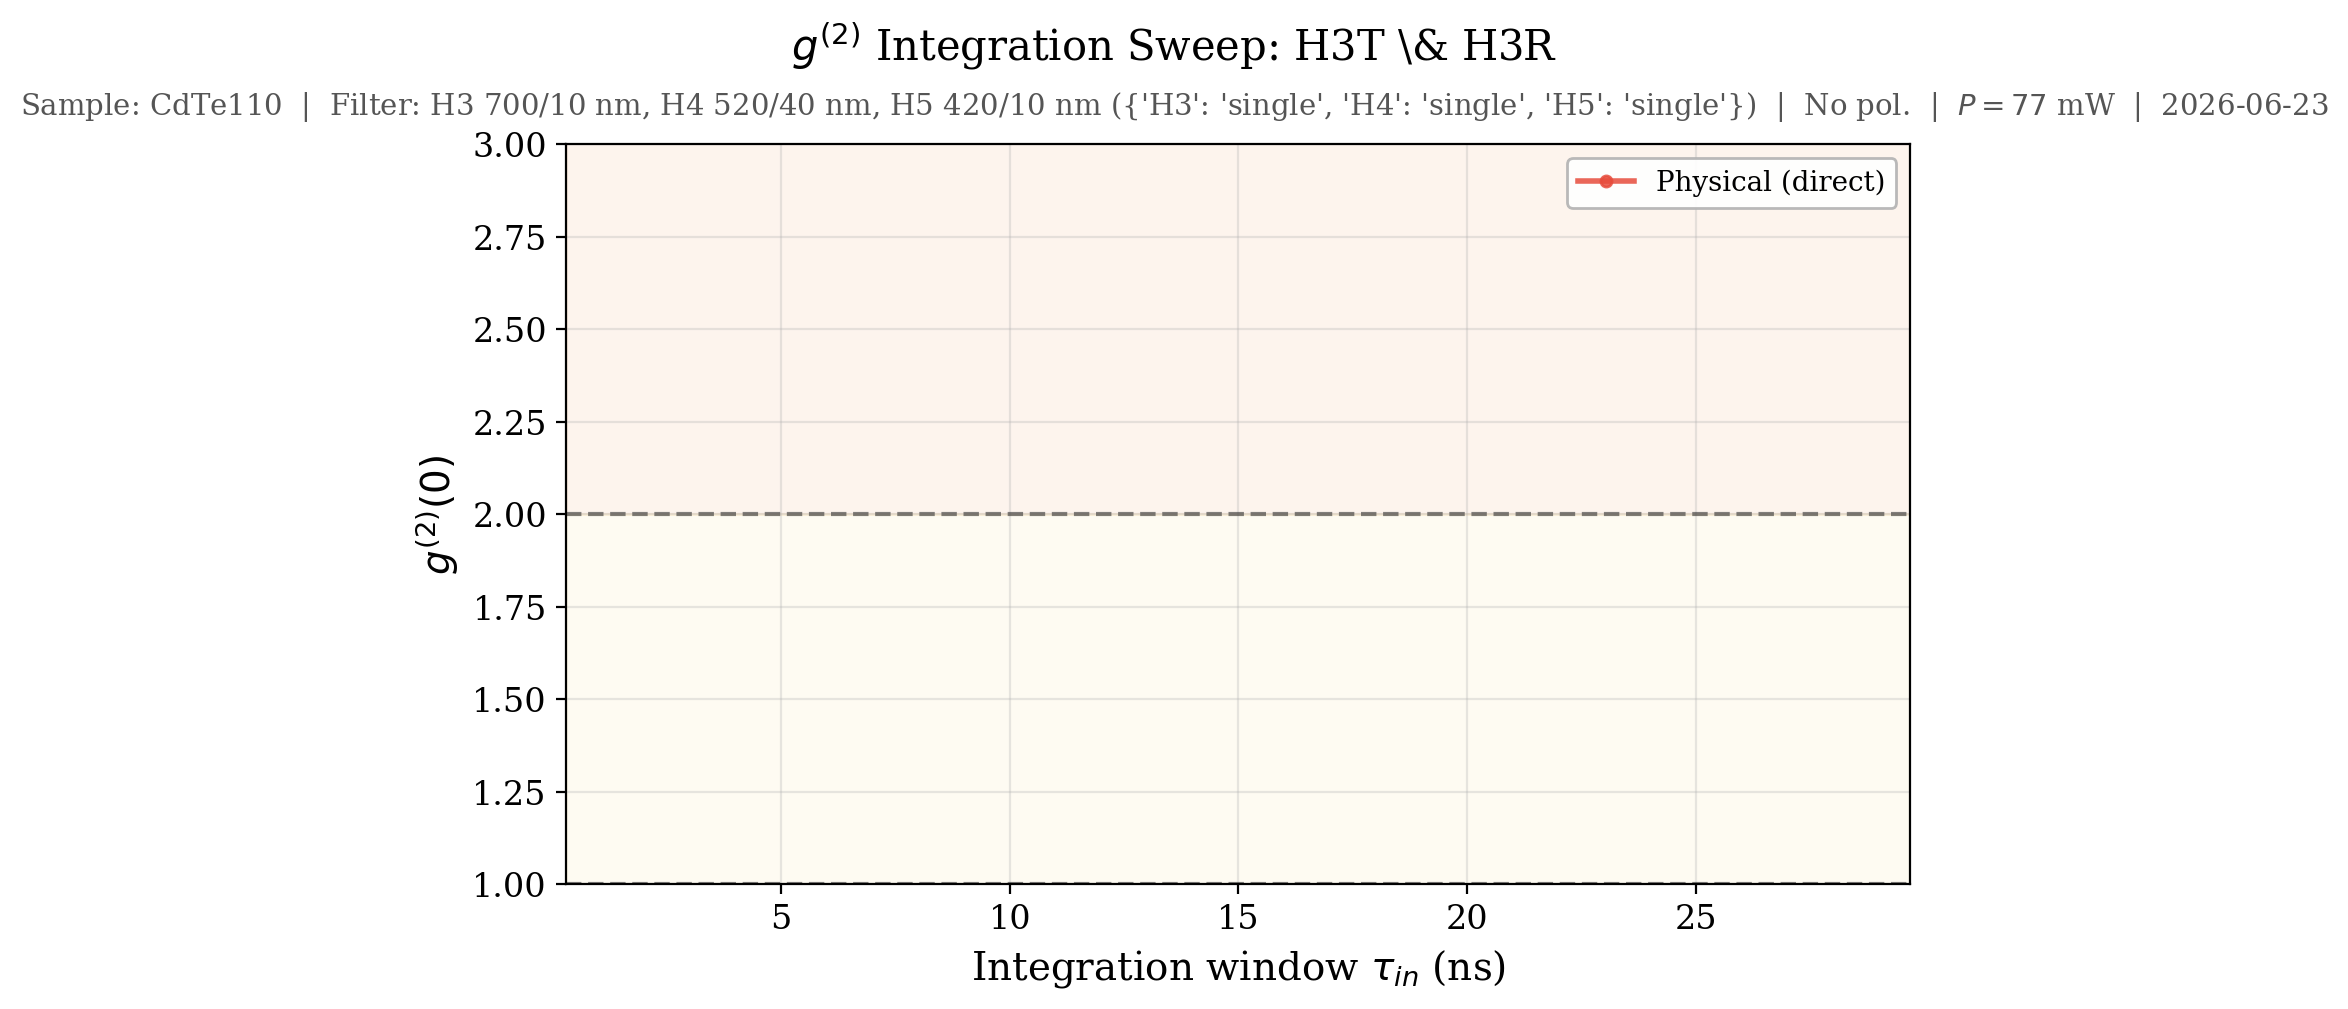

In [6]:
run = rep.runs[0]
fig, ax = rep.visu.plot_g2(run.get_ch("H3T"), run.get_ch("H3R"))
rep._display(fig)